## 0. Setup

In [56]:
# set libraries to refresh
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [57]:
# general
from pathlib import Path

import geopandas as gpd

# for plotting and coloring
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.colors import ListedColormap
from tqdm.notebook import tqdm

gpd.options.io_engine = "pyogrio"

In [58]:
from gridsample.utils import create_gmap_links, save_shapefiles
# from gridsample.mapping import create_interactive_map

In [59]:
from utils import (
    download_VIDA_rooftops_data_by_s2,
    generate_colormap,
    get_matched_rooftop_centroids_from_s2_file,
    get_s2_cell_ids,
    s2_cell_ids_to_shapes_gdf,
)

In [ ]:
ROOT_DIR = Path("../")
DATA_DIR = ROOT_DIR / "data_panel"
RAW_DATA_DIR = DATA_DIR / "01. Raw Data"  # symlinked from IFS folder
CLEANED_DATA_DIR = DATA_DIR / "02. Intermediate Outputs"
OUTPUT_DATA_DIR = DATA_DIR / "03. Final Outputs" / "v1_training"
OUTPUT_DATA_DIR.mkdir(parents=True, exist_ok=True)

## 1. Load MapSolve boundaries

In [61]:
# get all filepaths that end in `gpkg` inside the RAW_DATA_DIR / 0.1. MapSolve Boundaries
boundaries_dir = RAW_DATA_DIR / "01. MapSolve Boundaries"
gpkg_files_all = list(boundaries_dir.glob("**/*.gpkg"))
gpkg_files_all = [f for f in gpkg_files_all if f.is_file()]
# # drop any with the word "Sub-District" in the filename
# gpkg_files_VTW = [f for f in gpkg_files_all if "Sub-District" not in f.name]
# load all shapes into one gdf
gdf_list = []
for filepath in gpkg_files_all:
    gdf_list.append(gpd.read_file(filepath))
gdf = pd.concat(gdf_list, ignore_index=True).to_crs(4326)

In [62]:
gdf = gdf.drop_duplicates()

### Fix ad-hoc issues (see quality check notebook)

In [ ]:
# chittoor
gdf.loc[gdf["TV_C"] == 803014, ["SubDist_N", "SubDist_C"]] = ["Tirupati (Urban)", 5383]
# patna
gdf.loc[(gdf["TV_C"] == 801373) & (gdf["Ward_C"] == "3"), "PCA_ID"] = "801373-3"
# MDDS codes
gdf.loc[gdf["TV_C"] == 519923, ["TV_C", "Ward_C", "PCA_ID"]] = [802596, 18, "802596-18"]
gdf.loc[gdf["TV_C"] == 574077, ["TV_C", "Ward_C", "PCA_ID"]] = [
    802918,
    157,
    "802918-157",
]

<Axes: >

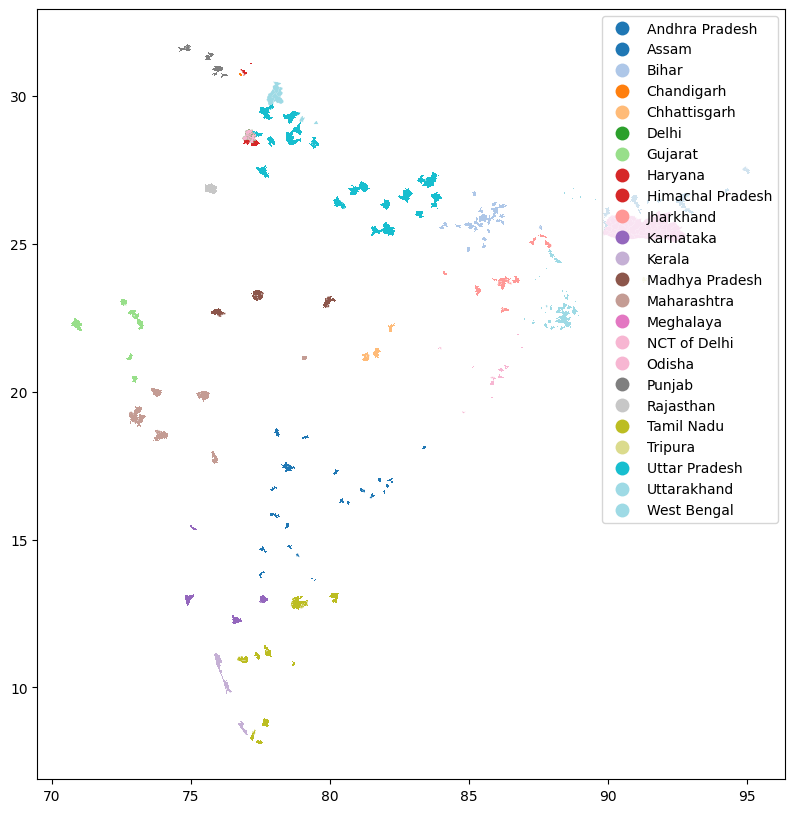

In [64]:
gdf.plot(column="State_N", legend=True, figsize=(10, 10), cmap="tab20")

## 2. Load sampled wards data

In [65]:
# load the merged wards data
sample_df = pd.read_csv(
    CLEANED_DATA_DIR
    / "00. Merge and Quality Checks"
    / "v1_training"
    / "Panel Wards with Quality Checks.csv"
)

In [66]:
sample_df

,State,State_Name,District,District_Name,Subdistrict,Subd_Name,TownVillage,UrbanWardVillage,WardVillage_Name,PCA_ID,...,Ward Boundary Available with MapSolve,State Shared by MapSolve,State Changed,Ward Boundary Given,TV Boundary Given,SubDistrict Boundary Given,Delivery State,PSU Type,PSU ID,Ward Count
0,20,JHARKHAND,364,Ranchi,2684,Kanke,801794,1,Ranchi (M Corp.) WARD NO.-0001,801794-1,...,Yes,True,No,True,False,False,GOOD - Ward boundary given as expected,ward,WARD_801794-1,1
1,20,JHARKHAND,364,Ranchi,2684,Kanke,801794,2,Ranchi (M Corp.) WARD NO.-0002,801794-2,...,Yes,True,No,True,False,False,GOOD - Ward boundary given as expected,ward,WARD_801794-2,1
2,20,JHARKHAND,364,Ranchi,2684,Kanke,801794,3,Ranchi (M Corp.) WARD NO.-0003,801794-3,...,Yes,True,No,True,False,False,GOOD - Ward boundary given as expected,ward,WARD_801794-3,1
3,20,JHARKHAND,364,Ranchi,2684,Kanke,801794,4,Ranchi (M Corp.) WARD NO.-0004,801794-4,...,Yes,True,No,True,False,False,GOOD - Ward boundary given as expected,ward,WARD_801794-4,1
4,20,JHARKHAND,364,Ranchi,2684,Kanke,801794,5,Ranchi (M Corp.) WARD NO.-0005,801794-5,...,Yes,True,No,True,False,False,GOOD - Ward boundary given as expected,ward,WARD_801794-5,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
215,22,CHHATTISGARH,410,Raipur,3332,Raipur,802035,11,Mana-Camp (NP) WARD NO.-0011,802035-11,...,Yes,True,No,True,False,False,GOOD - Ward boundary given as expected,ward,WARD_802035-11,1
216,22,CHHATTISGARH,410,Raipur,3332,Raipur,802035,12,Mana-Camp (NP) WARD NO.-0012,802035-12,...,Yes,True,No,True,False,False,GOOD - Ward boundary given as expected,ward,WARD_802035-12,1
217,22,CHHATTISGARH,410,Raipur,3332,Raipur,802035,13,Mana-Camp (NP) WARD NO.-0013,802035-13,...,Yes,True,No,True,False,False,GOOD - Ward boundary given as expected,ward,WARD_802035-13,1
218,22,CHHATTISGARH,410,Raipur,3332,Raipur,802035,14,Mana-Camp (NP) WARD NO.-0014,802035-14,...,Yes,True,No,True,False,False,GOOD - Ward boundary given as expected,ward,WARD_802035-14,1


### 2.1 Rename and clean both datasets

In [67]:
rename_dict = {
    "UID": "UID",
    "PCA_ID": "PCA_ID",
    "State_C": "State Code",
    "State_N": "State Name",
    "Dist_C": "District Code",
    "Dist_N": "District Name",
    "SubDist_C": "Subdistrict Code",
    "SubDist_N": "Subdistrict Name",
    "TV_C": "TV Code",
    "TV_N": "TV Name",
    "Ward_C": "Ward Code",
    "TOT_P": "Total Population",
}

gdf = gdf.rename(columns=rename_dict)

In [70]:
rename_dict = {
    "State": "State Code",
    "State_Name": "State Name",
    "District": "District Code",
    "District_Name": "District Name",
    "Subdistrict": "Subdistrict Code",
    "Subd_Name": "Subdistrict Name",
    "TownVillage": "TV Code",
    "UrbanWardVillage": "Ward Code",
    "WardVillage_Name": "Ward/Village Name",
    "TRU": "Urban/Rural",
    "WardVillage_Pop": "Ward Population",
    "Subd_Pop": "Subdistrict Population",
    "State_Pop": "State Population",
    "WardVillageID": "Complete ID",
}
sample_df = sample_df.rename(columns=rename_dict)

# make State Name heading case instead of all caps
sample_df["State Name"] = sample_df["State Name"].str.title()
sample_df.loc[sample_df["State Name"] == "Nct Of Delhi", "State Name"] = "NCT of Delhi"

In [71]:
# make relevant codes into floats for both datasets
code_columns = [
    "State Code",
    "District Code",
    "Subdistrict Code",
    "TV Code",
    "Ward Code",
]
for col in code_columns:
    sample_df[col] = sample_df[col].astype(float)
    gdf[col] = gdf[col].astype(float)

In [72]:
sample_df

,State Code,State Name,District Code,District Name,Subdistrict Code,Subdistrict Name,TV Code,Ward Code,Ward/Village Name,PCA_ID,...,Ward Boundary Available with MapSolve,State Shared by MapSolve,State Changed,Ward Boundary Given,TV Boundary Given,SubDistrict Boundary Given,Delivery State,PSU Type,PSU ID,Ward Count
0,20.0,Jharkhand,364.0,Ranchi,2684.0,Kanke,801794.0,1.0,Ranchi (M Corp.) WARD NO.-0001,801794-1,...,Yes,True,No,True,False,False,GOOD - Ward boundary given as expected,ward,WARD_801794-1,1
1,20.0,Jharkhand,364.0,Ranchi,2684.0,Kanke,801794.0,2.0,Ranchi (M Corp.) WARD NO.-0002,801794-2,...,Yes,True,No,True,False,False,GOOD - Ward boundary given as expected,ward,WARD_801794-2,1
2,20.0,Jharkhand,364.0,Ranchi,2684.0,Kanke,801794.0,3.0,Ranchi (M Corp.) WARD NO.-0003,801794-3,...,Yes,True,No,True,False,False,GOOD - Ward boundary given as expected,ward,WARD_801794-3,1
3,20.0,Jharkhand,364.0,Ranchi,2684.0,Kanke,801794.0,4.0,Ranchi (M Corp.) WARD NO.-0004,801794-4,...,Yes,True,No,True,False,False,GOOD - Ward boundary given as expected,ward,WARD_801794-4,1
4,20.0,Jharkhand,364.0,Ranchi,2684.0,Kanke,801794.0,5.0,Ranchi (M Corp.) WARD NO.-0005,801794-5,...,Yes,True,No,True,False,False,GOOD - Ward boundary given as expected,ward,WARD_801794-5,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
215,22.0,Chhattisgarh,410.0,Raipur,3332.0,Raipur,802035.0,11.0,Mana-Camp (NP) WARD NO.-0011,802035-11,...,Yes,True,No,True,False,False,GOOD - Ward boundary given as expected,ward,WARD_802035-11,1
216,22.0,Chhattisgarh,410.0,Raipur,3332.0,Raipur,802035.0,12.0,Mana-Camp (NP) WARD NO.-0012,802035-12,...,Yes,True,No,True,False,False,GOOD - Ward boundary given as expected,ward,WARD_802035-12,1
217,22.0,Chhattisgarh,410.0,Raipur,3332.0,Raipur,802035.0,13.0,Mana-Camp (NP) WARD NO.-0013,802035-13,...,Yes,True,No,True,False,False,GOOD - Ward boundary given as expected,ward,WARD_802035-13,1
218,22.0,Chhattisgarh,410.0,Raipur,3332.0,Raipur,802035.0,14.0,Mana-Camp (NP) WARD NO.-0014,802035-14,...,Yes,True,No,True,False,False,GOOD - Ward boundary given as expected,ward,WARD_802035-14,1


## 3. Filter MapSolve boundaries to sampled areas

### 3.2 Drop unnecessary rows 

#### Drop rows with no MapSolve shapes

In [73]:
sample_df[sample_df["PSU Type"] == "none"]

,State Code,State Name,District Code,District Name,Subdistrict Code,Subdistrict Name,TV Code,Ward Code,Ward/Village Name,PCA_ID,...,Ward Boundary Available with MapSolve,State Shared by MapSolve,State Changed,Ward Boundary Given,TV Boundary Given,SubDistrict Boundary Given,Delivery State,PSU Type,PSU ID,Ward Count
104,21.0,Odisha,386.0,Khordha,3055.0,Bhubaneswar (M.Corp.),801859.0,61.0,Industrial & Colony Area (OG) (Ward 61) WARD N...,801859-61,...,Yes,True,No,False,False,False,BAD - No boundary(s) given,none,SUBDISTRICT_3055,0
105,21.0,Odisha,386.0,Khordha,3055.0,Bhubaneswar (M.Corp.),801859.0,62.0,Industrial & Colony Area (OG) (Ward 62) WARD N...,801859-62,...,Yes,True,No,False,False,False,BAD - No boundary(s) given,none,SUBDISTRICT_3055,0
106,21.0,Odisha,386.0,Khordha,3055.0,Bhubaneswar (M.Corp.),801859.0,63.0,Industrial & Colony Area (OG) (Ward 63) WARD N...,801859-63,...,Yes,True,No,False,False,False,BAD - No boundary(s) given,none,SUBDISTRICT_3055,0
107,21.0,Odisha,386.0,Khordha,3055.0,Bhubaneswar (M.Corp.),801859.0,64.0,Industrial & Colony Area (OG) (Ward 64) WARD N...,801859-64,...,Yes,True,No,False,False,False,BAD - No boundary(s) given,none,SUBDISTRICT_3055,0
108,21.0,Odisha,386.0,Khordha,3055.0,Bhubaneswar (M.Corp.),801859.0,65.0,Industrial & Colony Area (OG) (Ward 65) WARD N...,801859-65,...,Yes,True,No,False,False,False,BAD - No boundary(s) given,none,SUBDISTRICT_3055,0
109,21.0,Odisha,386.0,Khordha,3055.0,Bhubaneswar (M.Corp.),801859.0,66.0,Industrial & Colony Area (OG) (Ward 66) WARD N...,801859-66,...,Yes,True,No,False,False,False,BAD - No boundary(s) given,none,SUBDISTRICT_3055,0
110,21.0,Odisha,386.0,Khordha,3055.0,Bhubaneswar (M.Corp.),801859.0,67.0,Industrial & Colony Area (OG) (Ward 67) WARD N...,801859-67,...,Yes,True,No,False,False,False,BAD - No boundary(s) given,none,SUBDISTRICT_3055,0
111,21.0,Odisha,386.0,Khordha,3055.0,Bhubaneswar (M.Corp.),801859.0,68.0,Industrial & Colony Area (OG) (Ward 68) WARD N...,801859-68,...,Yes,True,No,False,False,False,BAD - No boundary(s) given,none,SUBDISTRICT_3055,0
112,21.0,Odisha,386.0,Khordha,3055.0,Bhubaneswar (M.Corp.),801859.0,69.0,Patrapada (OG) WARD NO.-0069 (Rural MDDS CODE:...,801859-69,...,Yes,True,No,False,False,False,BAD - No boundary(s) given,none,SUBDISTRICT_3055,0
113,21.0,Odisha,386.0,Khordha,3055.0,Bhubaneswar (M.Corp.),801859.0,70.0,Sijuan (OG) WARD NO.-0070 (Rural MDDS CODE:408...,801859-70,...,Yes,True,No,False,False,False,BAD - No boundary(s) given,none,SUBDISTRICT_3055,0


In [74]:
filtered_df = sample_df[sample_df["PSU Type"] != "none"]

In [75]:
filtered_df

,State Code,State Name,District Code,District Name,Subdistrict Code,Subdistrict Name,TV Code,Ward Code,Ward/Village Name,PCA_ID,...,Ward Boundary Available with MapSolve,State Shared by MapSolve,State Changed,Ward Boundary Given,TV Boundary Given,SubDistrict Boundary Given,Delivery State,PSU Type,PSU ID,Ward Count
0,20.0,Jharkhand,364.0,Ranchi,2684.0,Kanke,801794.0,1.0,Ranchi (M Corp.) WARD NO.-0001,801794-1,...,Yes,True,No,True,False,False,GOOD - Ward boundary given as expected,ward,WARD_801794-1,1
1,20.0,Jharkhand,364.0,Ranchi,2684.0,Kanke,801794.0,2.0,Ranchi (M Corp.) WARD NO.-0002,801794-2,...,Yes,True,No,True,False,False,GOOD - Ward boundary given as expected,ward,WARD_801794-2,1
2,20.0,Jharkhand,364.0,Ranchi,2684.0,Kanke,801794.0,3.0,Ranchi (M Corp.) WARD NO.-0003,801794-3,...,Yes,True,No,True,False,False,GOOD - Ward boundary given as expected,ward,WARD_801794-3,1
3,20.0,Jharkhand,364.0,Ranchi,2684.0,Kanke,801794.0,4.0,Ranchi (M Corp.) WARD NO.-0004,801794-4,...,Yes,True,No,True,False,False,GOOD - Ward boundary given as expected,ward,WARD_801794-4,1
4,20.0,Jharkhand,364.0,Ranchi,2684.0,Kanke,801794.0,5.0,Ranchi (M Corp.) WARD NO.-0005,801794-5,...,Yes,True,No,True,False,False,GOOD - Ward boundary given as expected,ward,WARD_801794-5,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
215,22.0,Chhattisgarh,410.0,Raipur,3332.0,Raipur,802035.0,11.0,Mana-Camp (NP) WARD NO.-0011,802035-11,...,Yes,True,No,True,False,False,GOOD - Ward boundary given as expected,ward,WARD_802035-11,1
216,22.0,Chhattisgarh,410.0,Raipur,3332.0,Raipur,802035.0,12.0,Mana-Camp (NP) WARD NO.-0012,802035-12,...,Yes,True,No,True,False,False,GOOD - Ward boundary given as expected,ward,WARD_802035-12,1
217,22.0,Chhattisgarh,410.0,Raipur,3332.0,Raipur,802035.0,13.0,Mana-Camp (NP) WARD NO.-0013,802035-13,...,Yes,True,No,True,False,False,GOOD - Ward boundary given as expected,ward,WARD_802035-13,1
218,22.0,Chhattisgarh,410.0,Raipur,3332.0,Raipur,802035.0,14.0,Mana-Camp (NP) WARD NO.-0014,802035-14,...,Yes,True,No,True,False,False,GOOD - Ward boundary given as expected,ward,WARD_802035-14,1


In [76]:
# check bad rows, leave as is though
filtered_df[filtered_df["Delivery State"].str.contains("BAD")]

,State Code,State Name,District Code,District Name,Subdistrict Code,Subdistrict Name,TV Code,Ward Code,Ward/Village Name,PCA_ID,...,Ward Boundary Available with MapSolve,State Shared by MapSolve,State Changed,Ward Boundary Given,TV Boundary Given,SubDistrict Boundary Given,Delivery State,PSU Type,PSU ID,Ward Count


#### Drop duplicate rows if PSU is TV or Subdistrict

In [77]:
filtered_df = filtered_df[
    # if the PSU Type is "town_village", then drop any duplicated rows with the same TV Code
    ~(
        (filtered_df["PSU Type"] == "town_village")
        & (filtered_df.duplicated(subset=["TV Code"], keep="first"))
    )
    # similar for subdistrict
    & ~(
        (filtered_df["PSU Type"] == "subdistrict")
        & (filtered_df.duplicated(subset=["Subdistrict Code"], keep="first"))
    )
]

filtered_df.value_counts("PSU Type")

PSU Type
ward    197
Name: count, dtype: int64

#### Duplicated wards

In [78]:
filtered_df[filtered_df["PCA_ID"].duplicated(keep=False)]

,State Code,State Name,District Code,District Name,Subdistrict Code,Subdistrict Name,TV Code,Ward Code,Ward/Village Name,PCA_ID,...,Ward Boundary Available with MapSolve,State Shared by MapSolve,State Changed,Ward Boundary Given,TV Boundary Given,SubDistrict Boundary Given,Delivery State,PSU Type,PSU ID,Ward Count


In [79]:
print(f"Number of rows before dropping PCA_ID duplicates: {len(filtered_df)}")
print(
    f"Number of rows after dropping PCA_ID duplicates: {len(filtered_df.drop_duplicates(subset=['PCA_ID'], keep='first'))}"
)

Number of rows before dropping PCA_ID duplicates: 197
Number of rows after dropping PCA_ID duplicates: 197


In [80]:
filtered_df = filtered_df.drop_duplicates(subset=["PCA_ID"], keep="first")

#### Check for duplicated `PSU ID`

In [81]:
filtered_df[filtered_df.duplicated(subset=["PSU ID"], keep=False)]

,State Code,State Name,District Code,District Name,Subdistrict Code,Subdistrict Name,TV Code,Ward Code,Ward/Village Name,PCA_ID,...,Ward Boundary Available with MapSolve,State Shared by MapSolve,State Changed,Ward Boundary Given,TV Boundary Given,SubDistrict Boundary Given,Delivery State,PSU Type,PSU ID,Ward Count


In [82]:
filtered_df = filtered_df.drop_duplicates(subset=["PSU ID"], keep="first")
len(filtered_df) == filtered_df["PSU ID"].nunique()

True

## 4. Merge shapes at the respective PSU level

### Wards

In [83]:
# PCA IDs to match (TVCode-WardCode)
pca_ids_to_match = filtered_df.loc[filtered_df["PSU Type"] == "ward", "PCA_ID"].unique()
len(pca_ids_to_match)

197

In [84]:
wards_gdf = gpd.GeoDataFrame(
    filtered_df[filtered_df["PSU Type"] == "ward"].merge(
        gdf[gdf["PCA_ID"].isin(pca_ids_to_match)],
        on=["PCA_ID"],
        how="left",
        suffixes=("", "_MapSolve"),
    ),
    geometry="geometry",
)
wards_gdf.shape

(197, 37)

### Town/Village

In [85]:
# TV codes to match
tv_codes_to_match = filtered_df.loc[
    filtered_df["PSU Type"] == "town_village", "TV Code"
].unique()
len(tv_codes_to_match)

0

In [86]:
tv_gdf = gpd.GeoDataFrame(
    filtered_df[filtered_df["PSU Type"] == "town_village"].merge(
        gdf[gdf["TV Code"].isin(tv_codes_to_match) & gdf["Ward Code"].isna()],
        on=["TV Code"],
        how="left",
        suffixes=("", "_MapSolve"),
    )
)
tv_gdf.shape

(0, 37)

In [87]:
# cut out the ward geometries from the TV geometries so we don't double sample those areas
trimmed_tv_geoms = tv_gdf.difference(wards_gdf.geometry.unary_union)
trimmed_tv_gdf = gpd.GeoDataFrame(
    tv_gdf.drop(columns="geometry").assign(geometry=trimmed_tv_geoms),
    crs=tv_gdf.crs,
)

### Subdistrict

In [88]:
# subdistrict codes to match
subdistrict_codes_to_match = filtered_df.loc[
    filtered_df["PSU Type"] == "subdistrict", "Subdistrict Code"
].unique()
len(subdistrict_codes_to_match)

0

In [89]:
subdistrict_gdf = gpd.GeoDataFrame(
    filtered_df[filtered_df["PSU Type"] == "subdistrict"].merge(
        gdf[
            gdf["Subdistrict Code"].isin(subdistrict_codes_to_match)
            & (gdf["TV Code"].isna())
            & (gdf["Ward Code"].isna())
        ],
        on=["Subdistrict Code"],
        how="left",
        suffixes=("", "_MapSolve"),
    )
)

In [ ]:
# cut out the TV and Ward geometries from the subdistrict geometries so we don't double sample those areas
combined_tv_and_ward_union_shape = wards_gdf.geometry.unary_union.union(
    trimmed_tv_gdf.geometry.unary_union
)
if combined_tv_and_ward_union_shape:
    trimmed_subdistrict_geoms = subdistrict_gdf.difference(
        combined_tv_and_ward_union_shape
    )
else:
    trimmed_subdistrict_geoms = subdistrict_gdf.geometry

trimmed_subdistrict_gdf = gpd.GeoDataFrame(
    subdistrict_gdf.drop(columns="geometry").assign(geometry=trimmed_subdistrict_geoms),
    crs=subdistrict_gdf.crs,
)

/var/folders/99/cwxq7sdx5d94rqxj57_crqbc0000gn/T/ipykernel_9502/3553361681.py:3: FutureWarning: `unary_union` returned None due to all-None GeoSeries. In future, `unary_union` will return 'GEOMETRYCOLLECTION EMPTY' instead.
  trimmed_tv_gdf.geometry.unary_union


### Combine

In [95]:
# combine all three GeoDataFrames into one
combined_gdf = gpd.GeoDataFrame(
    pd.concat(
        [
            wards_gdf,
            trimmed_tv_gdf,
            trimmed_subdistrict_gdf,
        ],
        ignore_index=True,
    )
)
combined_gdf = combined_gdf.sort_values(
    by=["State Code", "District Code", "Subdistrict Code", "TV Code", "Ward Code"]
).reset_index(drop=True)

<Axes: >

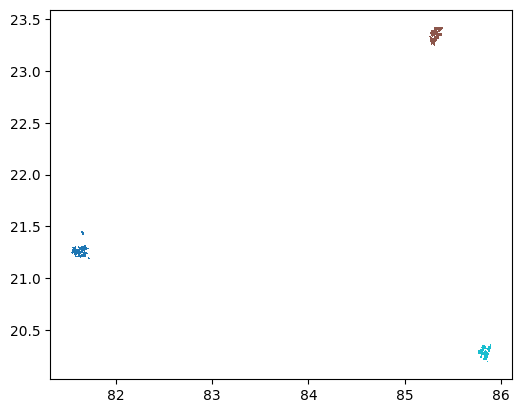

In [96]:
combined_gdf.plot(column="State Name")

### Drop rows duplicated `PSU ID` (could happen)

In [ ]:
duplicated_psu_id_gdf = combined_gdf[
    combined_gdf.duplicated(subset=["PSU ID"], keep=False)
]
duplicated_psu_id_gdf

,State Code,State Name,District Code,District Name,Subdistrict Code,Subdistrict Name,TV Code,Ward Code,Ward/Village Name,PCA_ID,...,District Code_MapSolve,District Name_MapSolve,Subdistrict Code_MapSolve,Subdistrict Name_MapSolve,TV Code_MapSolve,TV Name,Ward Code_MapSolve,Total Population,geometry,PCA_ID_MapSolve


In [98]:
duplicated_psu_id_gdf.groupby("PSU ID").plot(alpha=0.5, column="PSU ID", legend=True)

,State Code,State Name,District Code,District Name,Subdistrict Code,Subdistrict Name,TV Code,Ward Code,Ward/Village Name,PCA_ID,...,District Code_MapSolve,District Name_MapSolve,Subdistrict Code_MapSolve,Subdistrict Name_MapSolve,TV Code_MapSolve,TV Name,Ward Code_MapSolve,Total Population,geometry,PCA_ID_MapSolve
PSU ID,,,,,,,,,,,,,,,,,,,,,


In [99]:
combined_gdf = combined_gdf.drop_duplicates(subset=["PSU ID"], keep="first")
len(combined_gdf) == combined_gdf["PSU ID"].nunique()

True

In [100]:
combined_gdf["UID"] = combined_gdf["UID"].astype(str)

In [101]:
len(combined_gdf) == combined_gdf["PSU ID"].nunique()

True

In [102]:
save_shapefiles(
    combined_gdf,
    OUTPUT_DATA_DIR / "Sampled PSUs",
    "all_sampled_PSUs",
    ["csv", "parquet", "kml"],
)

/Users/amiremami/.pyenv/versions/geospatial/lib/python3.12/site-packages/pyogrio/raw.py:723: RuntimeWarning: Value 'Ranchi (M Corp.) WARD NO.-0001' of field all_sampled_PSUs.TV Code parsed incompletely to real 0.
  ogr_write(
/Users/amiremami/.pyenv/versions/geospatial/lib/python3.12/site-packages/pyogrio/raw.py:723: RuntimeWarning: Value '801794-1' of field all_sampled_PSUs.Ward Code parsed incompletely to real 801794.
  ogr_write(
/Users/amiremami/.pyenv/versions/geospatial/lib/python3.12/site-packages/pyogrio/raw.py:723: RuntimeWarning: Invalid value 'GOOD - Ward boundary given as expected' for boolean field all_sampled_PSUs.TV Boundary Given. Assuming it to be false.
  ogr_write(
/Users/amiremami/.pyenv/versions/geospatial/lib/python3.12/site-packages/pyogrio/raw.py:723: RuntimeWarning: Invalid value 'ward' for boolean field all_sampled_PSUs.SubDistrict Boundary Given. Assuming it to be false.
  ogr_write(
/Users/amiremami/.pyenv/versions/geospatial/lib/python3.12/site-packages/pyo

## 5. Download rooftops

#### Identify S2 cell IDs

In [103]:
s2_cell_ids = get_s2_cell_ids(combined_gdf)
len(s2_cell_ids)

Shapes with spillover after round 1: 0


/Users/amiremami/IDinsight Repos/rooftop_sampling/Panel/utils.py:126: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  points = gdf.geometry.centroid.to_frame(name="geometry")


3

#### Check if identified cells cover all areas of interest

In [104]:
s2_cells_gdf = s2_cell_ids_to_shapes_gdf(s2_cell_ids)

In [105]:
# Does the S2 cell cover the entire area of the boundaries?
uncovered_area = combined_gdf.unary_union.difference(s2_cells_gdf.unary_union).area
print(f"{uncovered_area} square degrees area not covered by an S2 cell")

0.0 square degrees area not covered by an S2 cell


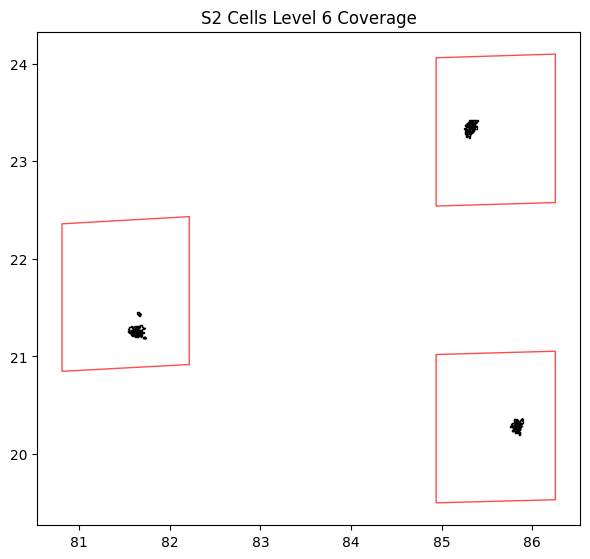

In [106]:
# Plot the S2 cells and the boundary
fig, ax = plt.subplots(1, 1, figsize=(6, 6))
combined_gdf.boundary.plot(ax=ax, color="black", linewidth=1)
s2_cells_gdf.plot(ax=ax, facecolor="none", edgecolor="red", alpha=0.7)
plt.title("S2 Cells Level 6 Coverage")
plt.tight_layout()
plt.show()

In [107]:
s2_cells_gdf_w_state = (
    s2_cells_gdf.sjoin(
        combined_gdf[["State Name", "geometry"]], how="inner", predicate="intersects"
    )
    .drop(columns="index_right")
    .drop_duplicates()
)

In [108]:
# note: this will have duplicate s2 cell rows with different state names if the s2 cell overlaps multiple states
# this is expected and is required for the next steps logic to work correctly
s2_cells_gdf_w_state

,s2_cell_id,geometry,State Name
0,4176244229456003072,"POLYGON ((84.94013 22.54055, 86.25649 22.57645...",Jharkhand
1,4186377328617586688,"POLYGON ((84.94013 19.49822, 86.25649 19.53012...",Odisha
2,4190880928244957184,"POLYGON ((80.81009 20.84638, 82.21486 20.91620...",Chhattisgarh


#### Download the S2 cells

In [109]:
download_VIDA_rooftops_data_by_s2(s2_cell_ids, "IND", RAW_DATA_DIR / "02. Rooftop Data")

File 4176244229456003072 already exists.
File 4186377328617586688 already exists.
File 4190880928244957184 already exists.


## 6. Load rooftops and match to areas

In [110]:
combined_gdf

,State Code,State Name,District Code,District Name,Subdistrict Code,Subdistrict Name,TV Code,Ward Code,Ward/Village Name,PCA_ID,...,District Code_MapSolve,District Name_MapSolve,Subdistrict Code_MapSolve,Subdistrict Name_MapSolve,TV Code_MapSolve,TV Name,Ward Code_MapSolve,Total Population,geometry,PCA_ID_MapSolve
0,20.0,Jharkhand,364.0,Ranchi,2684.0,Kanke,801794.0,1.0,Ranchi (M Corp.) WARD NO.-0001,801794-1,...,364.0,Ranchi,2684.0,Kanke,801794.0,Ranchi (M Corp.),1.0,9579.0,"MULTIPOLYGON (((85.31767 23.42379, 85.31794 23...",NaN
1,20.0,Jharkhand,364.0,Ranchi,2684.0,Kanke,801794.0,2.0,Ranchi (M Corp.) WARD NO.-0002,801794-2,...,364.0,Ranchi,2684.0,Kanke,801794.0,Ranchi (M Corp.),2.0,32200.0,"MULTIPOLYGON (((85.32630 23.42676, 85.32630 23...",NaN
2,20.0,Jharkhand,364.0,Ranchi,2684.0,Kanke,801794.0,3.0,Ranchi (M Corp.) WARD NO.-0003,801794-3,...,364.0,Ranchi,2684.0,Kanke,801794.0,Ranchi (M Corp.),3.0,13051.0,"MULTIPOLYGON (((85.34031 23.42255, 85.34031 23...",NaN
3,20.0,Jharkhand,364.0,Ranchi,2684.0,Kanke,801794.0,4.0,Ranchi (M Corp.) WARD NO.-0004,801794-4,...,364.0,Ranchi,2684.0,Kanke,801794.0,Ranchi (M Corp.),4.0,34708.0,"MULTIPOLYGON (((85.36376 23.42725, 85.36403 23...",NaN
4,20.0,Jharkhand,364.0,Ranchi,2684.0,Kanke,801794.0,5.0,Ranchi (M Corp.) WARD NO.-0005,801794-5,...,364.0,Ranchi,2684.0,Kanke,801794.0,Ranchi (M Corp.),5.0,19203.0,"MULTIPOLYGON (((85.38828 23.42478, 85.38828 23...",NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
192,22.0,Chhattisgarh,410.0,Raipur,3332.0,Raipur,802035.0,11.0,Mana-Camp (NP) WARD NO.-0011,802035-11,...,410.0,Raipur,3332.0,Raipur,802035.0,Mana-Camp (NP),11.0,409.0,"MULTIPOLYGON (((81.72100 21.18448, 81.71938 21...",NaN
193,22.0,Chhattisgarh,410.0,Raipur,3332.0,Raipur,802035.0,12.0,Mana-Camp (NP) WARD NO.-0012,802035-12,...,410.0,Raipur,3332.0,Raipur,802035.0,Mana-Camp (NP),12.0,1849.0,"MULTIPOLYGON (((81.73097 21.19202, 81.73124 21...",NaN
194,22.0,Chhattisgarh,410.0,Raipur,3332.0,Raipur,802035.0,13.0,Mana-Camp (NP) WARD NO.-0013,802035-13,...,410.0,Raipur,3332.0,Raipur,802035.0,Mana-Camp (NP),13.0,724.0,"MULTIPOLYGON (((81.72369 21.19378, 81.72369 21...",NaN
195,22.0,Chhattisgarh,410.0,Raipur,3332.0,Raipur,802035.0,14.0,Mana-Camp (NP) WARD NO.-0014,802035-14,...,410.0,Raipur,3332.0,Raipur,802035.0,Mana-Camp (NP),14.0,717.0,"MULTIPOLYGON (((81.72289 21.20057, 81.72315 21...",NaN


In [111]:
state_names = combined_gdf["State Name"].sort_values().unique()

for state_name in tqdm(state_names):
    print(f"Processing state: {state_name}")

    # Filter the s2 cells and rooftops gdf to the current state
    s2_cell_ids = set(
        s2_cells_gdf_w_state[s2_cells_gdf_w_state["State Name"] == state_name][
            "s2_cell_id"
        ]
    )
    print(
        f"Number of S2 cells that overlap our shapes in {state_name}: {len(s2_cell_ids)}"
    )
    gdf_subset = combined_gdf[combined_gdf["State Name"] == state_name]

    # Get matched rooftops for each S2 cell in the state
    matched_rooftop_centroids_gdf_list = []
    for s2_cell_id in tqdm(s2_cell_ids):
        matched_rooftop_centroids_gdf = get_matched_rooftop_centroids_from_s2_file(
            s2_file_dir=RAW_DATA_DIR / "02. Rooftop Data",
            s2_cell_id=s2_cell_id,
            boundaries_gdf=gdf_subset,
        )
        matched_rooftop_centroids_gdf_list.append(matched_rooftop_centroids_gdf)
    matched_rooftop_centroids_gdf = pd.concat(
        matched_rooftop_centroids_gdf_list, ignore_index=True
    )
    matched_rooftop_centroids_gdf["State Name"] = state_name

    # Save the matched rooftops data
    save_shapefiles(
        matched_rooftop_centroids_gdf,
        CLEANED_DATA_DIR / "01. Matched Rooftop Data" / "v1_training" / f"{state_name}",
        "matched_rooftops",
        ["parquet"],
    )

  0%|          | 0/3 [00:00<?, ?it/s]

Processing state: Chhattisgarh
Number of S2 cells that overlap our shapes in Chhattisgarh: 1


  0%|          | 0/1 [00:00<?, ?it/s]

/Users/amiremami/IDinsight Repos/rooftop_sampling/Panel/utils.py:223: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  s2_rooftops_gdf.geometry.centroid


Processing state: Jharkhand
Number of S2 cells that overlap our shapes in Jharkhand: 1


  0%|          | 0/1 [00:00<?, ?it/s]

/Users/amiremami/IDinsight Repos/rooftop_sampling/Panel/utils.py:223: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  s2_rooftops_gdf.geometry.centroid


Processing state: Odisha
Number of S2 cells that overlap our shapes in Odisha: 1


  0%|          | 0/1 [00:00<?, ?it/s]

/Users/amiremami/IDinsight Repos/rooftop_sampling/Panel/utils.py:223: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  s2_rooftops_gdf.geometry.centroid


In [112]:
# ax = matched_rooftop_centroids_gdf.sample(1000).plot(
#     cmap=ListedColormap(generate_colormap(len(matched_rooftop_centroids_gdf))),
# )
# gdf_subset.plot(ax=ax, color="none", edgecolor="black", linewidth=0.5)

## 7. Load matched rooftops

In [113]:
matched_rooftop_dir = CLEANED_DATA_DIR / "01. Matched Rooftop Data" / "v1_training"
all_filepaths = list(matched_rooftop_dir.glob("**/*.parquet"))
all_filepaths = [f for f in all_filepaths if f.is_file()]

# # filter to those that have selected_states in the name
# all_filepaths = [
#     f for f in all_filepaths if any(state in f.parent.name for state in selected_states)
# ]

# load all shapes into one gdf
matched_rooftops_gdf_list = []
for filepath in tqdm(all_filepaths):
    matched_rooftops_gdf_list.append(gpd.read_parquet(filepath))
matched_rooftops_gdf = gpd.GeoDataFrame(
    pd.concat(matched_rooftops_gdf_list, ignore_index=True)
).to_crs(4326)

  0%|          | 0/3 [00:00<?, ?it/s]

In [114]:
len(matched_rooftops_gdf)

809677

In [115]:
no_rooftop_PSU_IDs = set(combined_gdf["PSU ID"].unique()).difference(
    set(matched_rooftops_gdf["PSU ID"].unique())
)
no_rooftop_PSU_gdf = combined_gdf[combined_gdf["PSU ID"].isin(no_rooftop_PSU_IDs)]
no_rooftop_PSU_gdf

,State Code,State Name,District Code,District Name,Subdistrict Code,Subdistrict Name,TV Code,Ward Code,Ward/Village Name,PCA_ID,...,District Code_MapSolve,District Name_MapSolve,Subdistrict Code_MapSolve,Subdistrict Name_MapSolve,TV Code_MapSolve,TV Name,Ward Code_MapSolve,Total Population,geometry,PCA_ID_MapSolve


In [116]:
save_shapefiles(
    no_rooftop_PSU_gdf,
    OUTPUT_DATA_DIR / "Sampled PSUs",
    "PSUs_with_no_rooftops",
    ["csv", "kml"],
)

## 8. Sample rooftops

In [117]:
# Define the base number of rooftops per ward
ROOFTOPS_PER_WARD = 75

# Sample rooftops, multiplying by Ward Count for each PSU.
sampled_rooftops = matched_rooftops_gdf.groupby("PSU ID", group_keys=False).apply(
    lambda x: x.sample(
        n=min(ROOFTOPS_PER_WARD * int(x["Ward Count"].iloc[0]), x.shape[0]),
        random_state=42,
    )
)

In [118]:
print("Length of matched_rooftops_gdf:", len(matched_rooftops_gdf))
print("Length of sampled rooftops:", len(sampled_rooftops))

Length of matched_rooftops_gdf: 809677
Length of sampled rooftops: 14775


In [ ]:
# Check if Ward Count is correctly influencing sample sizes
TEMP_ward_count_df = matched_rooftops_gdf[["PSU ID", "Ward Count"]].drop_duplicates()
TEMP_ward_count_df["Expected Rooftop Count"] = (
    TEMP_ward_count_df["Ward Count"] * ROOFTOPS_PER_WARD
)
TEMP_sampled_counts = (sampled_rooftops.groupby("PSU ID").size()).reset_index(
    name="Sampled Rooftop Count"
)

# Merge the two dataframes
TEMP_check_df = TEMP_ward_count_df.merge(TEMP_sampled_counts, on="PSU ID")
TEMP_check_df["Rooftop Count Difference"] = (
    TEMP_check_df["Expected Rooftop Count"] - TEMP_check_df["Sampled Rooftop Count"]
)
TEMP_check_df[TEMP_check_df["Rooftop Count Difference"] != 0]

,PSU ID,Ward Count,Expected Rooftop Count,Sampled Rooftop Count,Rooftop Count Difference


<Axes: >

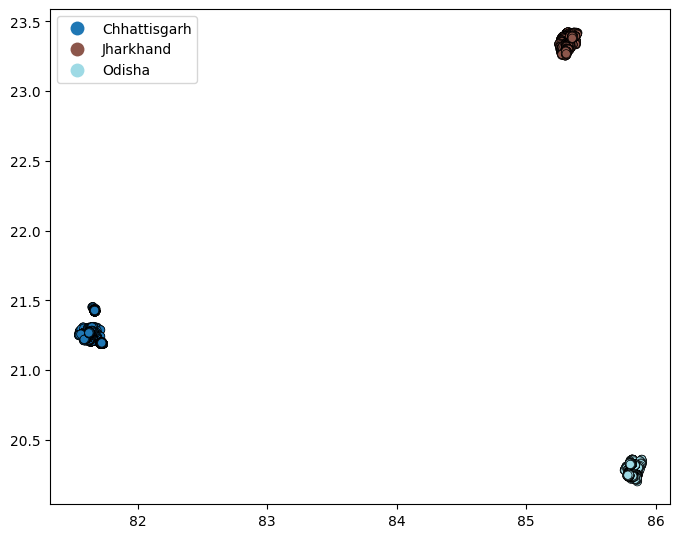

In [120]:
sampled_rooftops.plot(
    figsize=(8, 8),
    column="State Name",
    cmap="tab20",
    edgecolor="black",
    linewidth=0.5,
    legend=True,
)

### Add sample-level rooftop numbering ID columns

In [121]:
# Rooftop number within each state
sampled_rooftops["Rooftop State ID"] = (
    sampled_rooftops.groupby("State Name").cumcount() + 1
)

# Rooftop number within each PSU ID
sampled_rooftops["Rooftop PSU ID"] = sampled_rooftops.groupby("PSU ID").cumcount() + 1
# add prefix of "PIN "  to the Rooftop PSU ID
sampled_rooftops["Rooftop PSU ID"] = "PIN " + sampled_rooftops["Rooftop PSU ID"].astype(
    str
)

# Rooftop unique ID
sampled_rooftops["Rooftop Unique ID"] = sampled_rooftops.apply(
    lambda row: f"STATE_{row['Rooftop State ID']}_PSU_ID_{row['PSU ID']}_ROOFTOP_{row['Rooftop PSU ID']}",
    axis=1,
)

### Add gmap link

In [122]:
sampled_rooftops["latitude_original"] = sampled_rooftops.geometry.y
sampled_rooftops["longitude_original"] = sampled_rooftops.geometry.x
sampled_rooftops["gmap_link_original"] = create_gmap_links(
    df=sampled_rooftops,
    lat_name="latitude_original",
    lon_name="longitude_original",
)

### Select only useful columns

**Required columns:**
- PSU info
    - Unique ID across all rooftops
    - Rooftop state ID, #
    - Rooftop PSU ID, #

    - PSU Unit: Ward, TV, Subdistrict
    - PSU sample size

- geospatial info
    - google maps link
    - coordinates
    - geometry

- Admin location info
    - State code and name
    - District code and Name
    - Subdistrict code and name
    - TV code and name
    - Ward code and name

In [125]:
chosen_cols = [
    ## IDs
    "Rooftop State ID",
    "Rooftop PSU ID",
    "Rooftop Unique ID",
    ## Geospatial data
    "geometry",
    "latitude_original",
    "longitude_original",
    "gmap_link_original",
    ## PSU info
    "PSU ID",
    "PSU Type",
    "Ward Count",
    ## Location info
    "State Code",
    "State Name",
    "State Changed",
    "District Code",
    "District Name",
    "Subdistrict Code",
    "Subdistrict Name",
    "TV Code",
    "TV Name",  # (from MapSolve)
    "Ward Code",
    "Ward/Village Name",
    "Urban/Rural",
    "PCA_ID",  # combined TVCode-WardCode
    "Ward Population",
    "Subdistrict Population",
    "State Population",
    # "Complete ID",
    ## Admin information
    # "Included in Panel",
    "Ward Boundary Available with MapSolve",
    # "State Shared by MapSolve",
    "Ward Boundary Given",
    "TV Boundary Given",
    "SubDistrict Boundary Given",
    "Delivery State",
    # "UID",
    # "s2_rooftop_id",
    ## MapSolve location info
    "State Code_MapSolve",
    "State Name_MapSolve",
    "District Code_MapSolve",
    "District Name_MapSolve",
    "Subdistrict Code_MapSolve",
    "Subdistrict Name_MapSolve",
    "TV Code_MapSolve",
    # "TV Name",
    "Ward Code_MapSolve",
    "PCA_ID_MapSolve",
    "Total Population",
    # ## rooftop info
    # "boundary_id",
    # "bf_source",
    # "confidence",
    # "area_in_meters",
    # "s2_id",
    # "country_iso",
    # "geohash",
    # "bbox",
]

In [126]:
sampled_rooftops_organised_gdf = sampled_rooftops[chosen_cols]

In [127]:
sampled_rooftops_organised_gdf.rename(
    columns={
        "TV Name": "TV Name_MapSolve",
        "PSU ID": "PSU ID",
        "Total Population": "PSU Total Population_MapSolve",
    },
    inplace=True,
)

/var/folders/99/cwxq7sdx5d94rqxj57_crqbc0000gn/T/ipykernel_9502/357453037.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  sampled_rooftops_organised_gdf.rename(


In [128]:
# set Ward Codes of 0.0 to NaN
sampled_rooftops_organised_gdf.loc[
    sampled_rooftops_organised_gdf["Ward Code"] == 0.0, "Ward Code"
] = np.nan

In [129]:
sampled_rooftops_organised_gdf

,Rooftop State ID,Rooftop PSU ID,Rooftop Unique ID,geometry,latitude_original,longitude_original,gmap_link_original,PSU ID,PSU Type,Ward Count,...,State Code_MapSolve,State Name_MapSolve,District Code_MapSolve,District Name_MapSolve,Subdistrict Code_MapSolve,Subdistrict Name_MapSolve,TV Code_MapSolve,Ward Code_MapSolve,PCA_ID_MapSolve,PSU Total Population_MapSolve
777460,1,PIN 1,STATE_1_PSU_ID_WARD_801794-1_ROOFTOP_PIN 1,POINT (85.31096 23.39589),23.395887,85.310964,https://www.google.com/maps/search/?api=1&quer...,WARD_801794-1,ward,1,...,20.0,Jharkhand,364.0,Ranchi,2684.0,Kanke,801794.0,1.0,None,9579.0
780913,2,PIN 2,STATE_2_PSU_ID_WARD_801794-1_ROOFTOP_PIN 2,POINT (85.31659 23.42254),23.422539,85.316586,https://www.google.com/maps/search/?api=1&quer...,WARD_801794-1,ward,1,...,20.0,Jharkhand,364.0,Ranchi,2684.0,Kanke,801794.0,1.0,None,9579.0
779052,3,PIN 3,STATE_3_PSU_ID_WARD_801794-1_ROOFTOP_PIN 3,POINT (85.30983 23.41015),23.410149,85.309832,https://www.google.com/maps/search/?api=1&quer...,WARD_801794-1,ward,1,...,20.0,Jharkhand,364.0,Ranchi,2684.0,Kanke,801794.0,1.0,None,9579.0
780151,4,PIN 4,STATE_4_PSU_ID_WARD_801794-1_ROOFTOP_PIN 4,POINT (85.31163 23.41675),23.416745,85.311627,https://www.google.com/maps/search/?api=1&quer...,WARD_801794-1,ward,1,...,20.0,Jharkhand,364.0,Ranchi,2684.0,Kanke,801794.0,1.0,None,9579.0
779453,5,PIN 5,STATE_5_PSU_ID_WARD_801794-1_ROOFTOP_PIN 5,POINT (85.31369 23.41092),23.410915,85.313689,https://www.google.com/maps/search/?api=1&quer...,WARD_801794-1,ward,1,...,20.0,Jharkhand,364.0,Ranchi,2684.0,Kanke,801794.0,1.0,None,9579.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
425599,6971,PIN 71,STATE_6971_PSU_ID_WARD_802035-9_ROOFTOP_PIN 71,POINT (81.72122 21.19236),21.192355,81.721218,https://www.google.com/maps/search/?api=1&quer...,WARD_802035-9,ward,1,...,22.0,Chhattisgarh,410.0,Raipur,3332.0,Raipur,802035.0,9.0,None,1094.0
425732,6972,PIN 72,STATE_6972_PSU_ID_WARD_802035-9_ROOFTOP_PIN 72,POINT (81.72163 21.19551),21.195506,81.721634,https://www.google.com/maps/search/?api=1&quer...,WARD_802035-9,ward,1,...,22.0,Chhattisgarh,410.0,Raipur,3332.0,Raipur,802035.0,9.0,None,1094.0
425576,6973,PIN 73,STATE_6973_PSU_ID_WARD_802035-9_ROOFTOP_PIN 73,POINT (81.72029 21.19246),21.192465,81.720292,https://www.google.com/maps/search/?api=1&quer...,WARD_802035-9,ward,1,...,22.0,Chhattisgarh,410.0,Raipur,3332.0,Raipur,802035.0,9.0,None,1094.0
425604,6974,PIN 74,STATE_6974_PSU_ID_WARD_802035-9_ROOFTOP_PIN 74,POINT (81.71994 21.19273),21.192729,81.719937,https://www.google.com/maps/search/?api=1&quer...,WARD_802035-9,ward,1,...,22.0,Chhattisgarh,410.0,Raipur,3332.0,Raipur,802035.0,9.0,None,1094.0


### Save sampled data (original rooftop pins)

In [130]:
save_shapefiles(
    sampled_rooftops_organised_gdf,
    OUTPUT_DATA_DIR / "01. Sampled Rooftop Data",
    "sampled_rooftops_centroids_original",
    ["csv", "parquet"],
)

save_shapefiles(
    sampled_rooftops_organised_gdf.drop(columns=["gmap_link_original"]),
    OUTPUT_DATA_DIR / "01. Sampled Rooftop Data",
    "sampled_rooftops_centroids_original",
    ["kml"],
)

/Users/amiremami/.pyenv/versions/geospatial/lib/python3.12/site-packages/pyogrio/raw.py:723: RuntimeWarning: Value 'WARD_801794-1' of field sampled_rooftops_centroids_original.latitude_original parsed incompletely to real 0.
  ogr_write(
/Users/amiremami/.pyenv/versions/geospatial/lib/python3.12/site-packages/pyogrio/raw.py:723: RuntimeWarning: Value 'ward' of field sampled_rooftops_centroids_original.longitude_original parsed incompletely to real 0.
  ogr_write(
/Users/amiremami/.pyenv/versions/geospatial/lib/python3.12/site-packages/pyogrio/raw.py:723: RuntimeWarning: Value 'No' of field sampled_rooftops_centroids_original.State Code parsed incompletely to real 0.
  ogr_write(
/Users/amiremami/.pyenv/versions/geospatial/lib/python3.12/site-packages/pyogrio/raw.py:723: RuntimeWarning: Value 'Urban' of field sampled_rooftops_centroids_original.Ward Code parsed incompletely to real 0.
  ogr_write(
/Users/amiremami/.pyenv/versions/geospatial/lib/python3.12/site-packages/pyogrio/raw.py:72

## 9. Snap points to road

In [ ]:
import yaml
from shapely import Point

from utils import (
    get_nearest_points_on_road_batch,
    get_nearest_points_on_road_batch_parallel,
)

In [132]:
# load API key
with open("../secrets/api_keys.yaml", "r") as f:
    config = yaml.safe_load(f)
    api_key = config["GOOGLE_ROADS_API_KEY"]

In [ ]:
get_nearest_points_on_road_batch(
    [Point(77.11432151622034, 28.677391409999522)], api_key
)

[<POINT (77.114 28.677)>]

In [ ]:
# test
get_nearest_points_on_road_batch(
    sampled_rooftops_organised_gdf.geometry.iloc[:5], api_key
)

[<POINT (85.311 23.396)>,
 <POINT (85.317 23.423)>,
 <POINT (85.31 23.41)>,
 <POINT (85.312 23.417)>,
 <POINT (85.314 23.411)>]

In [ ]:
get_nearest_points_on_road_batch_parallel(
    sampled_rooftops_organised_gdf.iloc[:150], api_key
)

Snapping points to roads (batched):   0%|          | 0/2 [00:00<?, ?it/s]

777460    POINT (85.31110 23.39591)
780913    POINT (85.31659 23.42257)
779052    POINT (85.30990 23.41031)
780151    POINT (85.31156 23.41675)
779453    POINT (85.31371 23.41091)
                    ...            
699493    POINT (85.34185 23.36674)
700989    POINT (85.34683 23.37157)
700464    POINT (85.34597 23.37036)
699812    POINT (85.34613 23.36678)
699099    POINT (85.34159 23.36886)
Length: 150, dtype: geometry

#### Snap points to road

In [ ]:
snapped_points_series = get_nearest_points_on_road_batch_parallel(
    sampled_rooftops_organised_gdf, api_key, max_workers=12
)
# took 1 second for 1,600 points (Panel)
# 30s for all 53,000 points

Snapping points to roads (batched):   0%|          | 0/148 [00:00<?, ?it/s]

In [ ]:
sampled_rooftops_snapped_gdf = sampled_rooftops_organised_gdf.copy()
sampled_rooftops_snapped_gdf["geometry_snapped"] = (
    sampled_rooftops_snapped_gdf.index.map(snapped_points_series)
)

In [138]:
# Make new Geometry Type column which has values "Original" or "Snapped to Road"
sampled_rooftops_snapped_gdf["Geometry Type"] = (
    sampled_rooftops_snapped_gdf["geometry_snapped"]
    .notna()
    .replace({True: "Snapped to Road", False: "Original"})
)
sampled_rooftops_snapped_gdf["Geometry Type"].value_counts()

Geometry Type
Snapped to Road    14675
Original             100
Name: count, dtype: int64

#### Replace geometry to snapped one (missing filled in with original)

In [139]:
# backup the original geometry
sampled_rooftops_snapped_gdf["geometry_original"] = sampled_rooftops_snapped_gdf[
    "geometry"
]
# replace the original geometry with the snapped geometry
sampled_rooftops_snapped_gdf["geometry"] = sampled_rooftops_snapped_gdf[
    "geometry_snapped"
]
# drop the snapped geometry column
sampled_rooftops_snapped_gdf = sampled_rooftops_snapped_gdf.drop(
    columns=["geometry_snapped"]
)
# fill in NaN values in the snapped geometry with the original geometry
sampled_rooftops_snapped_gdf["geometry"] = sampled_rooftops_snapped_gdf[
    "geometry"
].fillna(sampled_rooftops_snapped_gdf["geometry_original"])

In [140]:
sampled_rooftops_snapped_gdf["geometry"].isna().sum()

0

#### Update lat, lon, gmap_link

In [141]:
sampled_rooftops_snapped_gdf["latitude"] = list(sampled_rooftops_snapped_gdf.geometry.y)
sampled_rooftops_snapped_gdf["longitude"] = list(
    sampled_rooftops_snapped_gdf.geometry.x
)
sampled_rooftops_snapped_gdf["gmap_link"] = create_gmap_links(
    df=sampled_rooftops_snapped_gdf,
    lat_name="latitude",
    lon_name="longitude",
)

#### Reorganise

In [142]:
sampled_rooftops_snapped_gdf = sampled_rooftops_snapped_gdf[
    [
        "Rooftop State ID",
        "Rooftop PSU ID",
        "Rooftop Unique ID",
        # new columns start
        "Geometry Type",
        "geometry",
        "latitude",
        "longitude",
        "gmap_link",
        # new columns end
        "geometry_original",
        "latitude_original",
        "longitude_original",
        "gmap_link_original",
        "PSU ID",
        "PSU Type",
        "Ward Count",
        "State Code",
        "State Name",
        "State Changed",
        "District Code",
        "District Name",
        "Subdistrict Code",
        "Subdistrict Name",
        "TV Code",
        "TV Name_MapSolve",
        "Ward Code",
        "Ward/Village Name",
        "Urban/Rural",
        "PCA_ID",
        "Ward Population",
        "Subdistrict Population",
        "State Population",
        # "Included in Panel",
        "Ward Boundary Available with MapSolve",
        "Ward Boundary Given",
        "TV Boundary Given",
        "SubDistrict Boundary Given",
        "Delivery State",
        "State Code_MapSolve",
        "State Name_MapSolve",
        "District Code_MapSolve",
        "District Name_MapSolve",
        "Subdistrict Code_MapSolve",
        "Subdistrict Name_MapSolve",
        "TV Code_MapSolve",
        "Ward Code_MapSolve",
        "PCA_ID_MapSolve",
        "PSU Total Population_MapSolve",
    ]
]

#### Make lines between original and snapped points

In [143]:
from shapely.geometry import LineString

In [144]:
sampled_rooftops_snapped_gdf["geometry_line"] = sampled_rooftops_snapped_gdf.apply(
    lambda row: LineString([row["geometry_original"], row["geometry"]]), axis=1
)

In [145]:
sampled_rooftops_snapped_gdf["geometry_line"].isna().sum()

0

#### Save new files: snapped points, snapped lines

In [146]:
# Save CSV and parquet
save_shapefiles(
    sampled_rooftops_snapped_gdf.drop(
        columns=[
            "geometry_original",
            "geometry_line",
        ]
    ),
    OUTPUT_DATA_DIR / "01. Sampled Rooftop Data",
    "sampled_rooftops_snapped_points",
    ["csv", "parquet"],
)

In [ ]:
# Save KML
save_shapefiles(
    sampled_rooftops_snapped_gdf.drop(
        columns=[
            "geometry_original",
            "geometry_line",
            # bad cols for KML
            "gmap_link_original",
            "gmap_link",
        ]
    ),
    OUTPUT_DATA_DIR / "01. Sampled Rooftop Data",
    "sampled_rooftops_snapped_points",
    ["kml"],
)

/Users/amiremami/.pyenv/versions/geospatial/lib/python3.12/site-packages/pyogrio/raw.py:723: RuntimeWarning: Value 'WARD_801794-1' of field sampled_rooftops_snapped_points.latitude_original parsed incompletely to real 0.
  ogr_write(
/Users/amiremami/.pyenv/versions/geospatial/lib/python3.12/site-packages/pyogrio/raw.py:723: RuntimeWarning: Value 'ward' of field sampled_rooftops_snapped_points.longitude_original parsed incompletely to real 0.
  ogr_write(
/Users/amiremami/.pyenv/versions/geospatial/lib/python3.12/site-packages/pyogrio/raw.py:723: RuntimeWarning: Value 'No' of field sampled_rooftops_snapped_points.State Code parsed incompletely to real 0.
  ogr_write(
/Users/amiremami/.pyenv/versions/geospatial/lib/python3.12/site-packages/pyogrio/raw.py:723: RuntimeWarning: Value 'Urban' of field sampled_rooftops_snapped_points.Ward Code parsed incompletely to real 0.
  ogr_write(
/Users/amiremami/.pyenv/versions/geospatial/lib/python3.12/site-packages/pyogrio/raw.py:723: RuntimeWarnin

In [148]:
# Save lines
sampled_rooftops_line_gdf = sampled_rooftops_snapped_gdf.copy()
sampled_rooftops_line_gdf["geometry"] = sampled_rooftops_line_gdf["geometry_line"]
sampled_rooftops_line_gdf = sampled_rooftops_line_gdf.drop(
    columns=["geometry_original", "geometry_line"]
)

save_shapefiles(
    sampled_rooftops_line_gdf.drop(
        # drop kml unfriendly columns
        columns=["gmap_link_original", "gmap_link"]
    ),
    OUTPUT_DATA_DIR / "01. Sampled Rooftop Data",
    "sampled_rooftops_snapped_lines",
    ["parquet", "kml"],
)

/Users/amiremami/.pyenv/versions/geospatial/lib/python3.12/site-packages/pyogrio/raw.py:723: RuntimeWarning: Value 'WARD_801794-1' of field sampled_rooftops_snapped_lines.latitude_original parsed incompletely to real 0.
  ogr_write(
/Users/amiremami/.pyenv/versions/geospatial/lib/python3.12/site-packages/pyogrio/raw.py:723: RuntimeWarning: Value 'ward' of field sampled_rooftops_snapped_lines.longitude_original parsed incompletely to real 0.
  ogr_write(
/Users/amiremami/.pyenv/versions/geospatial/lib/python3.12/site-packages/pyogrio/raw.py:723: RuntimeWarning: Value 'No' of field sampled_rooftops_snapped_lines.State Code parsed incompletely to real 0.
  ogr_write(
/Users/amiremami/.pyenv/versions/geospatial/lib/python3.12/site-packages/pyogrio/raw.py:723: RuntimeWarning: Value 'Urban' of field sampled_rooftops_snapped_lines.Ward Code parsed incompletely to real 0.
  ogr_write(
/Users/amiremami/.pyenv/versions/geospatial/lib/python3.12/site-packages/pyogrio/raw.py:723: RuntimeWarning: I

## Save per state

In [149]:
for state in tqdm(sampled_rooftops_organised_gdf["State Name"].unique()):
    state_output_folder = OUTPUT_DATA_DIR / "01. Sampled Rooftop Data" / state

    # save original points
    selected_state_original_gdf = sampled_rooftops_organised_gdf[
        sampled_rooftops_organised_gdf["State Name"] == state
    ]

    save_shapefiles(
        selected_state_original_gdf,
        state_output_folder,
        f"{state}_sampled_rooftops_centroids_original",
        ["csv", "parquet"],
    )
    save_shapefiles(
        selected_state_original_gdf.drop(
            # drop kml unfriendly columns
            columns=["gmap_link_original"]
        ),
        state_output_folder,
        f"{state}_sampled_rooftops_centroids_original",
        ["kml"],
    )

    # Save snapped points
    selected_state_snapped_gdf = sampled_rooftops_snapped_gdf[
        sampled_rooftops_snapped_gdf["State Name"] == state
    ].drop(
        columns=[
            "geometry_original",
            "geometry_line",
        ]
    )
    save_shapefiles(
        selected_state_snapped_gdf,
        state_output_folder,
        f"{state}_sampled_rooftops_snapped_points",
        ["csv", "parquet"],
    )
    save_shapefiles(
        selected_state_snapped_gdf.drop(
            # drop kml unfriendly columns
            columns=["gmap_link_original", "gmap_link"]
        ),
        state_output_folder,
        f"{state}_sampled_rooftops_snapped_points",
        ["kml"],
    )

    # Save lines
    selected_state_sampled_rooftops_line_gdf = sampled_rooftops_line_gdf[
        sampled_rooftops_line_gdf["State Name"] == state
    ]
    save_shapefiles(
        selected_state_sampled_rooftops_line_gdf.drop(
            # drop kml unfriendly columns
            columns=["gmap_link_original", "gmap_link"]
        ),
        state_output_folder,
        f"{state}_sampled_rooftops_snapped_lines",
        ["parquet", "kml"],
    )

  0%|          | 0/3 [00:00<?, ?it/s]

/Users/amiremami/.pyenv/versions/geospatial/lib/python3.12/site-packages/pyogrio/raw.py:723: RuntimeWarning: Value 'WARD_801794-1' of field Jharkhand_sampled_rooftops_centroids_original.latitude_original parsed incompletely to real 0.
  ogr_write(
/Users/amiremami/.pyenv/versions/geospatial/lib/python3.12/site-packages/pyogrio/raw.py:723: RuntimeWarning: Value 'ward' of field Jharkhand_sampled_rooftops_centroids_original.longitude_original parsed incompletely to real 0.
  ogr_write(
/Users/amiremami/.pyenv/versions/geospatial/lib/python3.12/site-packages/pyogrio/raw.py:723: RuntimeWarning: Value 'No' of field Jharkhand_sampled_rooftops_centroids_original.State Code parsed incompletely to real 0.
  ogr_write(
/Users/amiremami/.pyenv/versions/geospatial/lib/python3.12/site-packages/pyogrio/raw.py:723: RuntimeWarning: Value 'Urban' of field Jharkhand_sampled_rooftops_centroids_original.Ward Code parsed incompletely to real 0.
  ogr_write(
/Users/amiremami/.pyenv/versions/geospatial/lib/py